In [1]:
import os
import math
import pickle
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, cm

In [2]:
atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx]
cortex = np.where(atlas_only_brain != 0)[0]

In [3]:
participant_data_path = "/home/zachkaras/fmri/fmri_model_data/midprocess/133/filtered_func_data_clean.nii.gz"
fmri_data = nib.load(participant_data_path)
scan = fmri_data.get_fdata()

In [4]:
# reshape data to 2d
scan_2d = (np.reshape(scan, [scan.shape[0]*scan.shape[1]*scan.shape[2], scan.shape[3]]))

In [5]:
# z-score the data
means = scan_2d.mean(axis=1, keepdims=True)
stds = scan_2d.std(axis=1, keepdims=True)

z_scored_2d_scan = (scan_2d - means) / np.where(stds==0, 1, stds)

In [6]:
# Only looking at voxels in the MNI brain
scan_2d_brain = z_scored_2d_scan[brain_idx, :]

# Only looking at voxels labeled in the Schaefer Atlas
scan_2d_schaefer = scan_2d_brain[cortex,:]
scan_2d_schaefer = scan_2d_schaefer.T

In [7]:
scan_2d_schaefer.shape

(746, 131065)

In [14]:
with open("/home/zachkaras/fmri/133_vols_to_skip.pkl", 'rb') as f:
    vols_to_skip = pickle.load(f)

In [ ]:
vol_nums = np.ones((scan_2d_schaefer.shape)[0])
vol_nums[vols_to_skip] = 0

In [25]:
scan_2d_schaefer_filtered = scan_2d_schaefer[np.where(vol_nums == 1)]

In [ ]:
# TODO - map volume numbers to embeddings
#      - remove volumes for which we don't have data
with open("midprocess/133/code_formatted_keystrokes.pkl", 'rb') as f:
    keystrokes = pickle.load(f)
    


In [10]:
# load in embeddings
# embedding_path = '/home/zachkaras/fmri/fmri_model_data/fir_embeddings/codegemma_2b/133/code_keystroke_embeddings.pkl'
embedding_path = '/home/zachkaras/fmri/starcoder2_7b_code_fir_embeddings.pkl'

with open(embedding_path, 'rb') as f:
    embedding = pickle.load(f)

In [29]:
split_point = math.floor((scan_2d_schaefer_filtered.shape)[0]*0.9)
zRresp = scan_2d_schaefer_filtered[:split_point,:]
zPresp = scan_2d_schaefer_filtered[split_point:, :]

delRstim = embedding[:split_point, :]
delPstim = embedding[split_point:, :]

In [32]:

# try running bootstrap
from ridge import bootstrap_ridge

# delRstim from pickle files

# zRresp is fMRI data

# delPstim is prediction

# zPresp is fMRI data from prediction


alphas = np.logspace(1, 3, 10) # Equally log-spaced alphas between 10 and 1000. The third number is the number of alphas to test.
nboots = 1 # Number of cross-validation runs.
chunklen = 40 # 
nchunks = 20

wt, corr, alphas, bscorrs, valinds = bootstrap_ridge(delRstim, zRresp, delPstim, zPresp,
                                                     alphas, nboots, chunklen, nchunks,
                                                     singcutoff=1e-10, single_alpha=True)



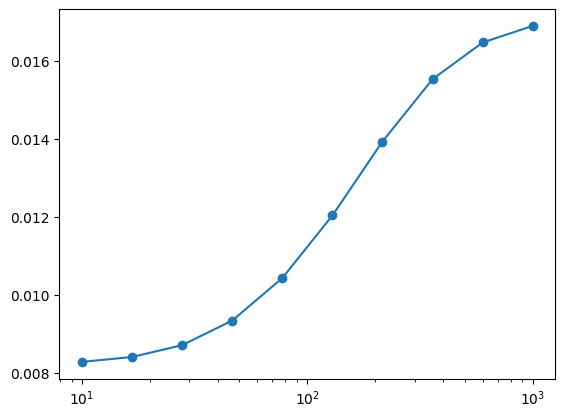

In [33]:
f = figure()
ax = f.add_subplot(1,1,1)
ax.semilogx( np.logspace(1, 3, 10), bscorrs.mean(2).mean(1), 'o-')

In [34]:
pred = np.dot(delPstim, wt)

print ("pred has shape: ", pred.shape)

pred has shape:  (69, 131065)


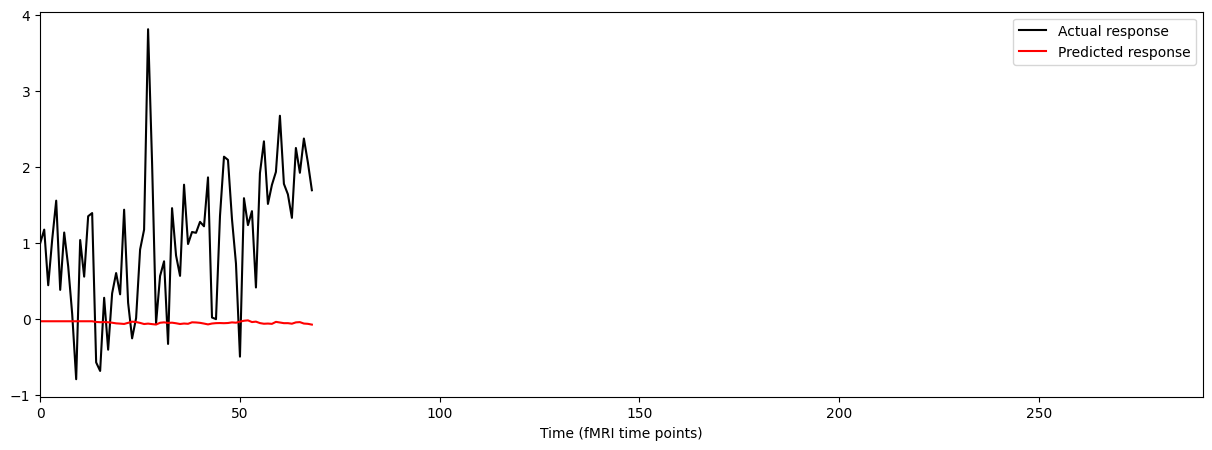

In [35]:
f = figure(figsize=(15,5))
ax = f.add_subplot(1,1,1)

selvox = 20710 # a decent voxel

realresp = ax.plot(zPresp[:,selvox], 'k')[0]
predresp = ax.plot(pred[:,selvox], 'r')[0]

ax.set_xlim(0, 291)
ax.set_xlabel("Time (fMRI time points)")

ax.legend((realresp, predresp), ("Actual response", "Predicted response"));

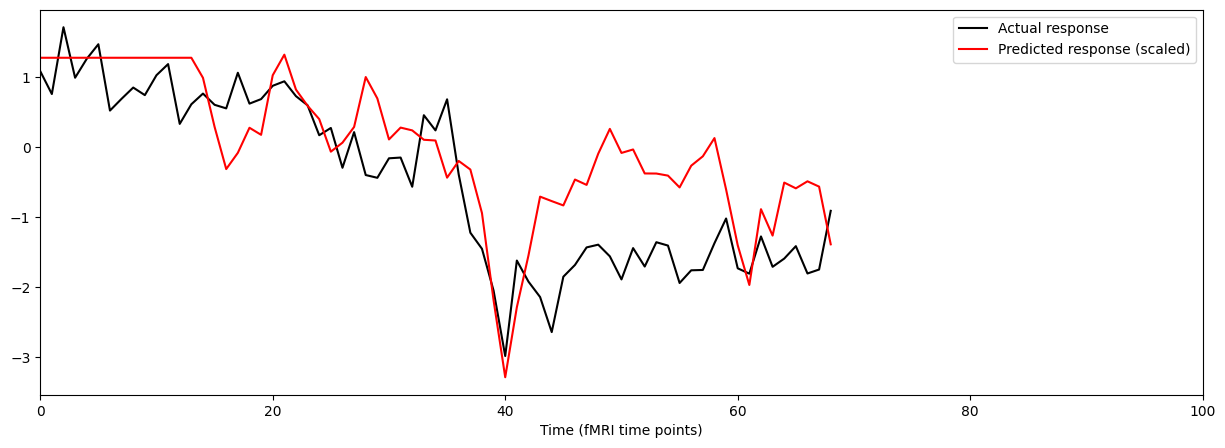

In [54]:
from npp import zscore

f = figure(figsize=(15,5))
ax = f.add_subplot(1,1,1)

selvox = 65806 # a good voxel
# selvox = 34232 # a good voxel
# selvox = 130745 # a good voxel
selvox = 38035 # a good voxel
# selvox = 51219
# selvox = 121999

realresp = ax.plot(zPresp[:,selvox], 'k')[0]
predresp = ax.plot(zscore(pred[:,selvox]), 'r')[0]

ax.set_xlim(0, 100)
ax.set_xlabel("Time (fMRI time points)")

ax.legend((realresp, predresp), ("Actual response", "Predicted response (scaled)"));

In [38]:
voxcorrs = np.zeros((zPresp.shape[1],)) # create zero-filled array to hold correlations
for vi in range(zPresp.shape[1]):
    voxcorrs[vi] = np.corrcoef(zPresp[:,vi], pred[:,vi])[0,1]
print (voxcorrs)

[-0.40943505  0.16949179 -0.32263515 ...  0.41026802  0.67993311
 -0.50991054]


In [48]:
np.where(voxcorrs > 0.8)


(array([ 38035,  51219,  57145,  78043,  95267, 121999, 130363, 130398,
        130925]),)

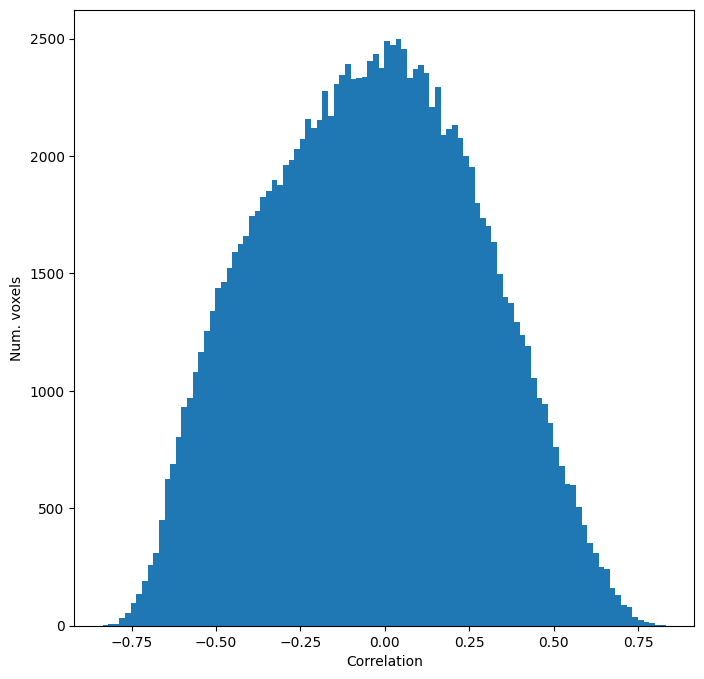

In [39]:
f = figure(figsize=(8,8))
ax = f.add_subplot(1,1,1)
ax.hist(voxcorrs, 100) # histogram correlations with 100 bins
ax.set_xlabel("Correlation")
ax.set_ylabel("Num. voxels");